# Multiprocessing and Functional Programming
**Beginner Level Tasks**

In [1]:
# Install required libraries (run once)
!pip install yfinance pandas matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import time
import math
import requests
from io import StringIO
from functools import reduce
from multiprocessing import Pool, cpu_count

---
## Task 1 — Multiprocessing
### 1a. Getting to know `yfinance`

`yfinance` is a Python library that lets us download historical stock price data from Yahoo Finance.
It returns a pandas DataFrame with columns: Open, High, Low, Close, Volume.

In [3]:
# Download 1 year of Apple stock data as a quick demo
data = yf.download("AAPL", period="1y")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-03-13,208.770081,215.899013,207.515554,215.012876,61368300
2025-03-14,212.563553,213.021548,208.670517,210.333268,60107600
2025-03-17,213.071350,214.286057,209.058839,212.384342,48073400
2025-03-18,211.767029,214.216345,210.572239,213.230651,42432400
2025-03-19,214.305969,217.810683,212.822430,213.290391,54385400


### 1b. Download S&P 500 stock prices — Single Process vs Multiprocessing

First, we fetch the list of S&P 500 tickers from Wikipedia.
Wikipedia blocks default requests, so we pass a browser-like `User-Agent` header.

In [4]:
# Get S&P 500 ticker list from Wikipedia
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    headers=headers
)

table = pd.read_html(StringIO(response.text))[0]
tickers = table["Symbol"].tolist()

print(f"Total tickers: {len(tickers)}")
tickers[:10]

Total tickers: 503


['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [5]:
# Helper function to download a single ticker
def download_stock(ticker, period="1y"):
    return yf.download(ticker, period=period, progress=False)

In [7]:
# Single Process: download tickers one by one in a loop 
start = time.time()

single_data = {}
for t in tickers[:50]:
    data = download_stock(t)
    if not data.empty:
        single_data[t] = data

single_time = time.time() - start
print(f"Single process time: {single_time:.2f}s")
print(f"Successfully downloaded: {len(single_data)}/50 tickers")
print(f"Downloaded tickers: {list(single_data.keys())}")

Single process time: 59.29s
Successfully downloaded: 50/50 tickers
Downloaded tickers: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO']


In [8]:
#  Multiprocessing: download all tickers in parallel using yfinance built-in threading 
# yfinance's batch download with threads=True distributes requests across threads internally
start = time.time()

multi_data = yf.download(
    tickers[:50],
    period="1y",
    group_by="ticker",
    threads=True
)

multi_time = time.time() - start
print(f"Multiprocessing time: {multi_time:.2f}s")

[*********************100%***********************]  50 of 50 completed


Multiprocessing time: 8.43s


### 1c. Compare and Visualize Results

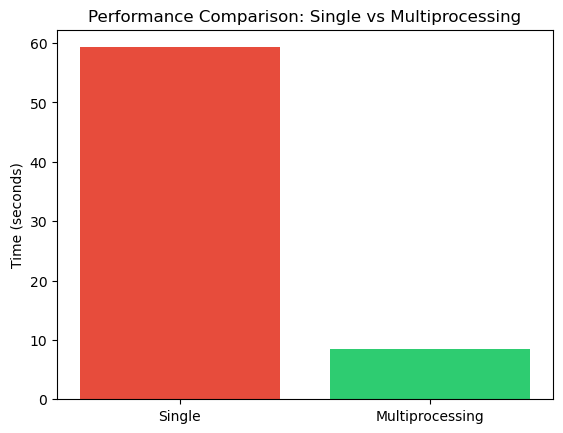

Speedup: 7.0x faster with multiprocessing


In [9]:
# Bar chart comparing execution times
plt.bar(["Single", "Multiprocessing"], [single_time, multi_time], color=["#e74c3c", "#2ecc71"])
plt.ylabel("Time (seconds)")
plt.title("Performance Comparison: Single vs Multiprocessing")
plt.show()

print(f"Speedup: {single_time / multi_time:.1f}x faster with multiprocessing")

---
## Task 2 — Functional Programming
### 2a. `map`, `filter`, `functools.reduce`

#### a1. First attempt — without external resources

In [10]:
ls = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# Square all numbers
squared = list(map(lambda x: x**2, ls))
print("Squared:", squared)

# Keep only primes
def is_prime(n):
    if n < 2:
        return False
    for i in range(2, n):
        if n % i == 0:
            return False
    return True

primes = list(filter(is_prime, ls))
print("Primes:", primes)

# Sum of squares
sum_sq = reduce(lambda x, y: x + y, squared)
print("Sum of squares:", sum_sq)

# MSE — mean squared error relative to target value 5
target = 5
mse = reduce(lambda acc, x: acc + (x - target)**2, ls, 0) / len(ls)
print("MSE:", mse)

Squared: [1, 4, 9, 16, 25, 36, 49, 64, 81]
Primes: [2, 3, 5, 7]
Sum of squares: 285
MSE: 6.666666666666667


#### a2. Improved version — after research

Key improvement: checking divisors only up to `sqrt(n)` makes `is_prime` much more efficient.

In [11]:
ls = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# More efficient primality check using sqrt
def is_prime(n):
    if n < 2:
        return False
    return all(n % i != 0 for i in range(2, int(math.sqrt(n)) + 1))

# Square all numbers
squared = list(map(lambda x: x**2, ls))
print("Squared:", squared)

# Keep only primes
primes = list(filter(is_prime, ls))
print("Primes:", primes)

# Sum of squares
sum_sq = reduce(lambda x, y: x + y, squared)
print("Sum of squares:", sum_sq)

# MSE — mean squared error relative to target value 5
target = 5
mse = reduce(lambda acc, x: acc + (x - target)**2, ls, 0) / len(ls)
print(f"MSE (target={target}):", mse)

Squared: [1, 4, 9, 16, 25, 36, 49, 64, 81]
Primes: [2, 3, 5, 7]
Sum of squares: 285
MSE (target=5): 6.666666666666667


### 2b. Lambda functions with `pd.DataFrame.apply()`

`apply()` lets us run a function on each element of a column (element-wise) or each row of a DataFrame (row-wise with `axis=1`).

In [12]:
df = pd.DataFrame({"values": ls})

# Apply lambdas to create new columns
df["squared"] = df["values"].apply(lambda x: x**2)
df["is_prime"] = df["values"].apply(lambda x: is_prime(x))

df

,values,squared,is_prime
0,1,1,False
1,2,4,True
2,3,9,True
3,4,16,False
4,5,25,True
5,6,36,False
6,7,49,True
7,8,64,False
8,9,81,False


---
### 2c. Word Count using `map`, `reduce`, and sorting

Classic MapReduce pattern:
- **map** → emit `(word, 1)` pairs for each word
- **reduce** → aggregate counts per word
- **sorted** → rank by frequency

In [13]:
text = "data science is fun and data science is powerful"
words = text.split()

# map: assign count 1 to each word
mapped = list(map(lambda w: (w, 1), words))
print("Mapped:", mapped)

Mapped: [('data', 1), ('science', 1), ('is', 1), ('fun', 1), ('and', 1), ('data', 1), ('science', 1), ('is', 1), ('powerful', 1)]


In [14]:
# reduce: aggregate counts into a dictionary
def count_words(acc, pair):
    word, count = pair
    acc[word] = acc.get(word, 0) + count
    return acc

word_counts = reduce(count_words, mapped, {})

# sort by count descending
sorted_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
print("Word counts (sorted):", sorted_counts)

Word counts (sorted): [('data', 2), ('science', 2), ('is', 2), ('fun', 1), ('and', 1), ('powerful', 1)]
